In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pathlib import Path
from sklearn.cluster import KMeans
from matplotlib.gridspec import GridSpec

sns.set_context('talk')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlepad'] = 12


connections_princeton.csv → defines the graph topology

classification.csv → defines attributes of nodes, not edges

In [26]:
DATA_DIR = Path('../data/raw')
CONNECTIONS_PATH = DATA_DIR / 'connections_princeton.csv'
ANNOTATIONS_PATH = DATA_DIR / 'classification.csv.gz'

EDGE_WEIGHT_COL = 'syn_count'

assert CONNECTIONS_PATH.exists(), 'connections_princeton.csv missing'
CONNECTIONS_PATH
assert ANNOTATIONS_PATH.exists(), 'classification.csv.gz missing'
ANNOTATIONS_PATH
MIN_SYN = 5

In [27]:
connections = pd.read_csv(CONNECTIONS_PATH)
connections = connections[['pre_root_id', 'post_root_id', EDGE_WEIGHT_COL, 'neuropil', 'nt_type']]
connections.head()


,pre_root_id,post_root_id,neuropil,syn_count,nt_type
0,720575940625363947,720575940623224444,ME_L,12,GABA
1,720575940630432382,720575940618518557,ME_L,67,ACH
2,720575940627314521,720575940626337738,ME_L,10,GABA
3,720575940620280405,720575940620204726,ME_L,15,ACH
4,720575940636942447,720575940613789411,LA_L,1,GLUT


In [14]:
ann = pd.read_csv(ANNOTATIONS_PATH)  # works with .csv.gz
ann.columns = [c.strip() for c in ann.columns]

# Quick sanity: see what columns exist
print("Annotation columns:", ann.columns.tolist())

# IMPORTANT: check naming in 'class' / 'sub_class' (yours may differ slightly)
for col in ["super_class", "class", "sub_class", "flow"]:
    if col in ann.columns:
        print(f"\nTop values in {col}:")
        print(ann[col].value_counts(dropna=False).head(15))

# Search for strings to learn the exact naming used in your file
def show_matches(col, pattern, max_show=30):
    if col not in ann.columns: 
        return
    vals = ann[col].dropna().astype(str)
    hits = sorted(set([v for v in vals.unique() if pattern.lower() in v.lower()]))
    print(f"\nMatches for '{pattern}' in {col} ({len(hits)}):")
    print(hits[:max_show])

for col in ["class", "sub_class"]:
    show_matches(col, "MBON")
    show_matches(col, "Kenyon")
    show_matches(col, "KC")
    show_matches(col, "PN")

Annotation columns: ['root_id', 'flow', 'super_class', 'class', 'sub_class', 'hemilineage', 'side', 'nerve']

Top values in super_class:
super_class
optic                 77865
central               32388
sensory               16946
visual_projection      7684
ascending              2362
descending             1303
visual_centrifugal      521
motor                   106
endocrine                80
Name: count, dtype: int64

Top values in class:
class
optic_lobe_intrinsic    77001
NaN                     32235
visual                  11434
Kenyon_Cell              5177
CX                       2869
mechanosensory           2651
AN                       2362
olfactory                2281
ALPN                      685
LHLN                      514
ALLN                      427
gustatory                 343
DAN                       331
bilateral                 220
TuBu                      150
Name: count, dtype: int64

Top values in sub_class:
sub_class
NaN                   42880
trans

# CREATING THE SUBNETWORK

In [29]:
# 1) Define ROI nodes by anatomy (no edge direction assumptions)
pns   = set(ann.loc[ann["class"].isin(["ALPN", "TPN"]), "root_id"].astype(int))
kcs   = set(ann.loc[ann["class"] == "Kenyon_Cell", "root_id"].astype(int))
mbons = set(ann.loc[ann["class"] == "MBON", "root_id"].astype(int))
roi_nodes = pns | kcs | mbons
print(f"PN: {len(pns)}, KC: {len(kcs)}, MBON: {len(mbons)}")
print(f"ROI nodes (before pruning): {len(roi_nodes)}")


# 2) Keep ALL directed edges among ROI nodes (direction preserved)
connections_roi = connections[
    connections["pre_root_id"].isin(roi_nodes) &
    connections["post_root_id"].isin(roi_nodes)
].copy()
print("Edges in ROI (before pruning):", len(connections_roi))


# 3) Optional noise filter: prune weak edges
MIN_SYN = 10
connections_roi = connections_roi[connections_roi[EDGE_WEIGHT_COL] >= MIN_SYN].copy()
print("Edges after synapse threshold:", len(connections_roi))

# 4) Cap to <= 1000 nodes without bias (by total strength within ROI)
out_strength = connections_roi.groupby("pre_root_id")[EDGE_WEIGHT_COL].sum()
in_strength  = connections_roi.groupby("post_root_id")[EDGE_WEIGHT_COL].sum()
strength = out_strength.add(in_strength, fill_value=0)

MAX_NODES = 1000
keep_nodes = strength.sort_values(ascending=False).head(MAX_NODES).index

connections_roi = connections_roi[
    connections_roi["pre_root_id"].isin(keep_nodes) &
    connections_roi["post_root_id"].isin(keep_nodes)
].copy()

print("Final nodes:", len(keep_nodes))
print("Final edges:", len(connections_roi))

keep_set = set(keep_nodes)
print("Kept PN:", len(keep_set & pns))
print("Kept KC:", len(keep_set & kcs))
print("Kept MBON:", len(keep_set & mbons))


# =====  build adj from connections_roi (NOT from connections) =====
node_list = pd.Index(sorted(keep_nodes))
node_to_idx = {n: i for i, n in enumerate(node_list)}

connections_roi["pre_idx"]  = connections_roi["pre_root_id"].map(node_to_idx)
connections_roi["post_idx"] = connections_roi["post_root_id"].map(node_to_idx)

n = len(node_list)
adj = np.zeros((n, n), dtype=float)
for _, row in connections_roi.iterrows():
    adj[int(row["pre_idx"]), int(row["post_idx"])] += row[EDGE_WEIGHT_COL]

print(f'Nodes kept: {n}, edges kept: {len(connections_roi):,}, total synapses: {connections_roi[EDGE_WEIGHT_COL].sum():,}')
adj


PN: 687, KC: 5177, MBON: 96
ROI nodes (before pruning): 5960
Edges in ROI (before pruning): 143943
Edges after synapse threshold: 24583
Final nodes: 1000
Final edges: 5953
Kept PN: 364
Kept KC: 576
Kept MBON: 60
Nodes kept: 1000, edges kept: 5,953, total synapses: 147,590


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1000, 1000))

## Network Analysis 


#### Basic structure of the PN–KC–MBON subnetwork

In [31]:
print("Nodes:", G_roi.number_of_nodes())
print("Edges:", G_roi.number_of_edges())
print("Density:", nx.density(G_roi))


Nodes: 5960
Edges: 47029
Density: 0.0013241771794060308


In [65]:
nodes = set(G_roi.nodes())

n_pn   = len(nodes & pns)
n_kc   = len(nodes & kcs)
n_mbon = len(nodes & mbons)

print("PN nodes:", n_pn)
print("KC nodes:", n_kc)
print("MBON nodes:", n_mbon)
print("Total nodes:", n_pn + n_kc + n_mbon)


PN nodes: 687
KC nodes: 5177
MBON nodes: 96
Total nodes: 5960


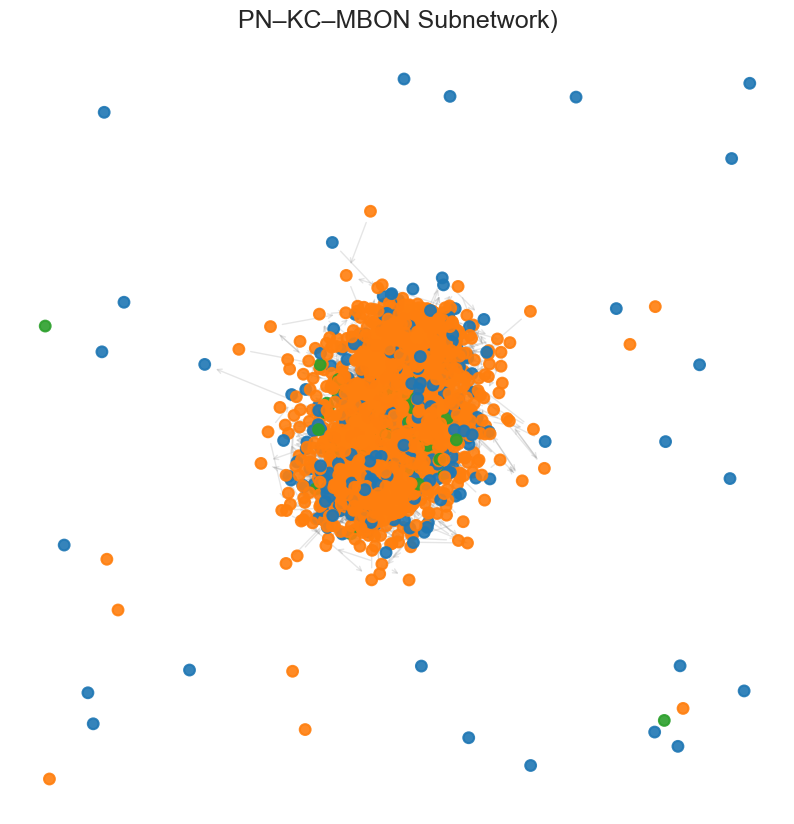

In [66]:
color_map = []
for n in G_roi.nodes():
    if n in pns:
        color_map.append("tab:blue")     # PN
    elif n in kcs:
        color_map.append("tab:orange")   # KC
    elif n in mbons:
        color_map.append("tab:green")    # MBON
    else:
        color_map.append("gray")
pos = nx.spring_layout(G_roi, seed=42)
plt.figure(figsize=(10, 10))

nx.draw_networkx_nodes(
    G_roi,
    pos,
    node_color=color_map,
    node_size=60,
    alpha=0.9
)

nx.draw_networkx_edges(
    G_roi,
    pos,
    arrowstyle="->",
    arrowsize=8,
    edge_color="gray",
    alpha=0.2
)

plt.title("PN–KC–MBON Subnetwork)")
plt.axis("off")
plt.show()



#### In-degree & out-degree (strength) distributions


In [34]:
out_strength = adj.sum(axis=1)   # sum of outgoing weights
in_strength  = adj.sum(axis=0)   # sum of incoming weights
df_strength = pd.DataFrame({
    "out_strength": out_strength,
    "in_strength": in_strength,
    "node": node_list
})

def node_type(n):
    if n in pns: return "PN"
    if n in kcs: return "KC"
    if n in mbons: return "MBON"
    return "Other"

df_strength["type"] = df_strength["node"].map(node_type)


In [35]:
# Averages by type
df_strength.groupby("type")[["out_strength", "in_strength"]].mean()


,out_strength,in_strength
type,,
KC,11.611111,126.590278
MBON,318.833333,431.266667
PN,334.538462,134.060440


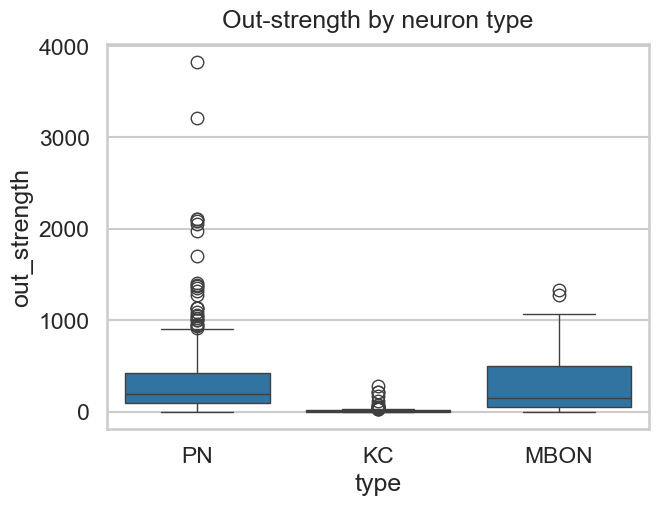

In [36]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df_strength, x="type", y="out_strength")
plt.title("Out-strength by neuron type")
plt.show()


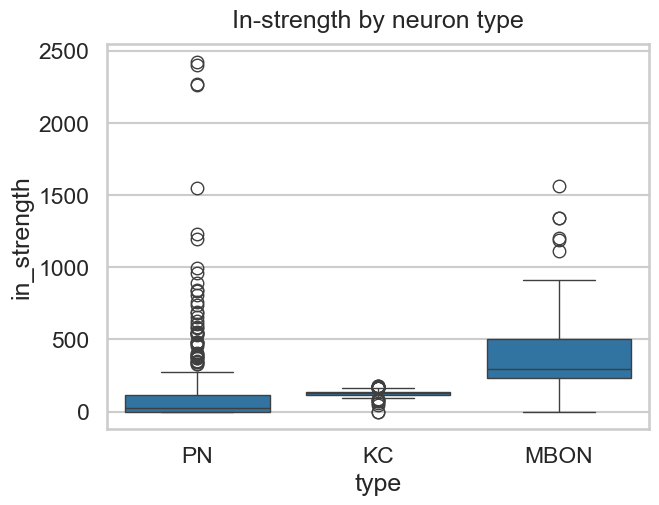

In [37]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df_strength, x="type", y="in_strength")
plt.title("In-strength by neuron type")
plt.show()


PN

- High out-strength

- Low in-strength

- Act as source nodes

KC

- Intermediate out-strength

- Intermediate in-strength

- Act as relay / processing nodes

MBON

- High in-strength

- Low out-strength

- Act as sink nodes

#### Do directed paths in the PN–KC–MBON subnetwork follow the expected feedforward pattern, and do Kenyon Cells act as intermediates between PN and MBON?

We will check three things:

1) PN → MBON reachability

2) Whether shortest paths go through KC

3) Typical path lengths

In [38]:
pn_nodes   = list(pns & set(G_roi.nodes))
mbon_nodes = list(mbons & set(G_roi.nodes))

reachable_pairs = 0
total_pairs = 0

for pn in pn_nodes:
    reachable = nx.descendants(G_roi, pn)
    for mbon in mbon_nodes:
        total_pairs += 1
        if mbon in reachable:
            reachable_pairs += 1

print("PN → MBON reachable pairs:", reachable_pairs)
print("Total PN–MBON pairs:", total_pairs)
print("Reachability fraction:", reachable_pairs / total_pairs)


PN → MBON reachable pairs: 48222
Total PN–MBON pairs: 65952
Reachability fraction: 0.7311681222707423


This high fraction indicates a directed feedforward backbone

In [39]:
# We measure path length,
path_lengths = []

for pn in pn_nodes:
    for mbon in mbon_nodes:
        if nx.has_path(G_roi, pn, mbon):
            try:
                length = nx.shortest_path_length(G_roi, pn, mbon)
                path_lengths.append(length)
            except nx.NetworkXNoPath:
                pass

pd.Series(path_lengths).describe()


count    48222.000000
mean         3.476525
std          0.979465
min          1.000000
25%          3.000000
50%          3.000000
75%          4.000000
max          9.000000
dtype: float64

Typical path length ≈ 3

This short path support efficient feedforward transmission

### Do shortest paths pass through KC?

In [41]:
kc_nodes = set(kcs & set(G_roi.nodes))

paths_through_kc = 0
total_paths = 0

for pn in pn_nodes:
    for mbon in mbon_nodes:
        if nx.has_path(G_roi, pn, mbon):
            path = nx.shortest_path(G_roi, pn, mbon)
            total_paths += 1
            if any(node in kc_nodes for node in path[1:-1]):
                paths_through_kc += 1

print("Paths via KC:", paths_through_kc)
print("Total PN → MBON paths:", total_paths)
print("Fraction via KC:", paths_through_kc / total_paths)


Paths via KC: 43934
Total PN → MBON paths: 48222
Fraction via KC: 0.9110779312347062


High fraction means KC nodes are structural intermediates

Confirms the PN → KC → MBON architecture

PN nodes initiate many directed paths

MBON nodes terminate many directed paths

KC nodes lie on a large fraction of shortest paths

### Centrality , Betweenness centrality , Bottlenecks in directed networks

Which neurons lie on many shortest directed paths, and therefore control or mediate information flow in the PN–KC–MBON subnetwork?

In [43]:
bc = nx.betweenness_centrality(G_roi, normalized=True, weight=None)


In [46]:
df_bc = pd.DataFrame({
    "node": list(bc.keys()),
    "betweenness": list(bc.values())
})

df_bc["type"] = df_bc["node"].map(node_type)
df_bc = pd.DataFrame({
    "node": list(bc.keys()),
    "betweenness": list(bc.values())
})

df_bc["type"] = df_bc["node"].map(node_type)




In [47]:
#Compare betweenness across PN / KC / MBON
df_bc.groupby("type")["betweenness"].mean()


type
KC      0.000054
MBON    0.018137
PN      0.003200
Name: betweenness, dtype: float64

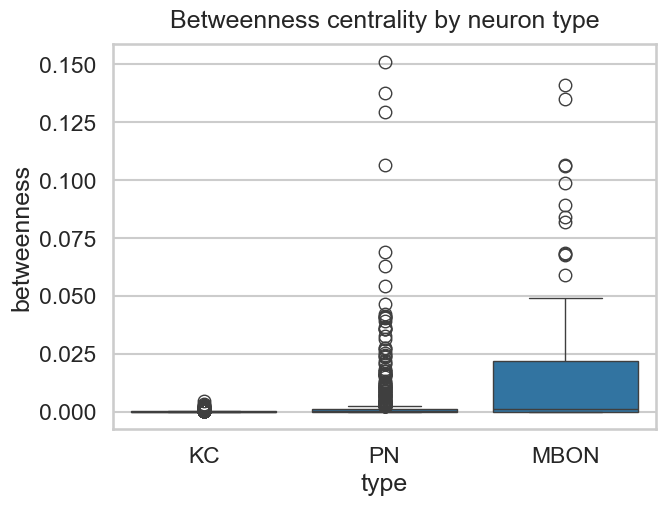

In [48]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df_bc, x="type", y="betweenness")
plt.title("Betweenness centrality by neuron type")
plt.show()


How do different neuron types connect to each other, and is connectivity dominated by feedforward (PN → KC → MBON) rather than recurrent interactions?

In [50]:
edges = []

for u, v in G_roi.edges():
    edges.append({
        "src_type": node_type(u),
        "tgt_type": node_type(v)
    })

df_edges = pd.DataFrame(edges)
mix = pd.crosstab(df_edges["src_type"], df_edges["tgt_type"])
mix



tgt_type,KC,MBON,PN
src_type,,,
KC,4904,15182,8
MBON,86,376,33
PN,22192,28,4220


In [51]:
#Normalize by outgoing edges (row-normalized)
mix_norm = mix.div(mix.sum(axis=1), axis=0)
mix_norm


tgt_type,KC,MBON,PN
src_type,,,
KC,0.244053,0.755549,0.000398
MBON,0.173737,0.759596,0.066667
PN,0.839334,0.001059,0.159607


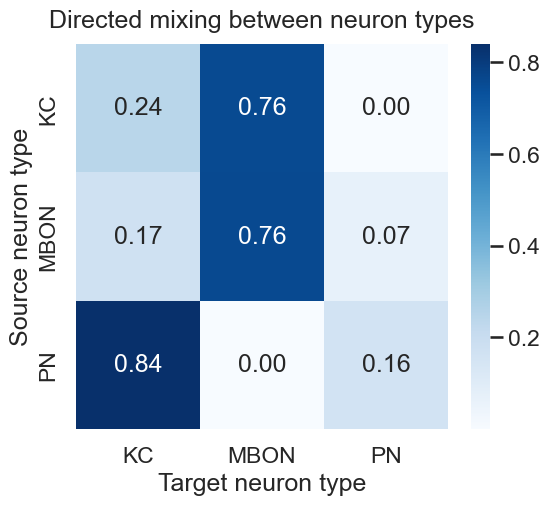

In [52]:
plt.figure(figsize=(6,5))
sns.heatmap(mix_norm, annot=True, cmap="Blues", fmt=".2f")
plt.title("Directed mixing between neuron types")
plt.xlabel("Target neuron type")
plt.ylabel("Source neuron type")
plt.show()


- PNs act as source nodes, primarily forwarding information to KCs rather than directly to MBONs
- KCs function as relay / processing nodes, transmitting information downstream to MBONs while maintaining limited internal connectivity.
- MBONs act primarily as sink nodes, where information accumulates, with limited feedback connections.

### Comparison with a null model (is the structure non-random?)

Is the strong PN → KC → MBON organization simply a consequence of node degrees, or does it represent genuine structural organization?

In [54]:
#Build a randomized network
G_rand = G_roi.copy()

# Degree-preserving randomization for directed graphs
nx.algorithms.swap.directed_edge_swap(
    G_rand,
    nswap=10 * G_rand.number_of_edges(),
    max_tries=100 * G_rand.number_of_edges()
)


In [55]:
mix_real = pd.crosstab(
    df_edges["src_type"],
    df_edges["tgt_type"],
    normalize="index"
)


In [56]:
edges_rand = [
    {"src_type": node_type(u), "tgt_type": node_type(v)}
    for u, v in G_rand.edges()
]

df_rand = pd.DataFrame(edges_rand)

mix_rand = pd.crosstab(
    df_rand["src_type"],
    df_rand["tgt_type"],
    normalize="index"
)


In [57]:
mix_diff = mix_real - mix_rand
mix_diff


tgt_type,KC,MBON,PN
src_type,,,
KC,-0.210660,0.279735,-0.069075
MBON,-0.319192,0.333333,-0.014141
PN,0.166074,-0.218835,0.052761


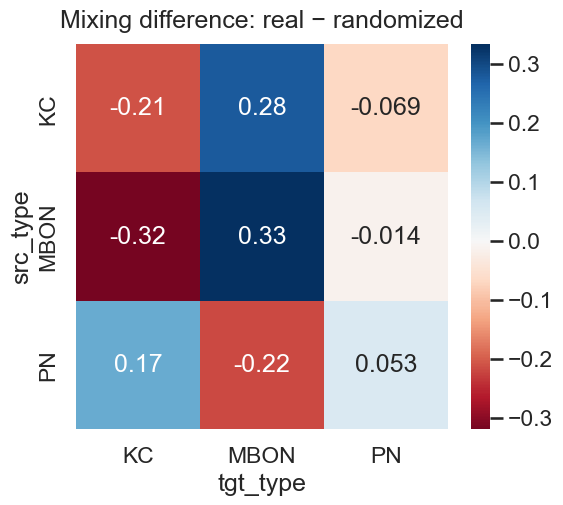

In [58]:
plt.figure(figsize=(6,5))
sns.heatmap(mix_diff, annot=True, center=0, cmap="RdBu")
plt.title("Mixing difference: real − randomized")
plt.show()


The PN → KC → MBON pathway is not an artifact of degree distribution.

Feedforward connections are selectively enhanced, while shortcuts and feedback are selectively suppressed.

This confirms genuine mesoscale organization consistent with a layered, directional architecture, not random wiring.

### Core–periphery structure and hierarchical layering

This analysis asks where each neuron type sits structurally: core vs periphery.

For directed graphs, we use the undirected projection for structural cohesion

In [60]:
#Compute k-core decomposition
G_und = G_roi.to_undirected()

core_num = nx.core_number(G_und)


In [61]:
df_core = pd.DataFrame({
    "node": list(core_num.keys()),
    "core": list(core_num.values())
})

df_core["type"] = df_core["node"].map(node_type)


In [62]:
df_core.groupby("type")["core"].describe()


,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
KC,5177.0,8.063357,2.179858,0.0,7.0,8.0,10.0,11.0
MBON,96.0,8.541667,3.460808,0.0,5.0,11.0,11.0,11.0
PN,687.0,7.883552,3.526386,0.0,5.0,10.0,11.0,11.0


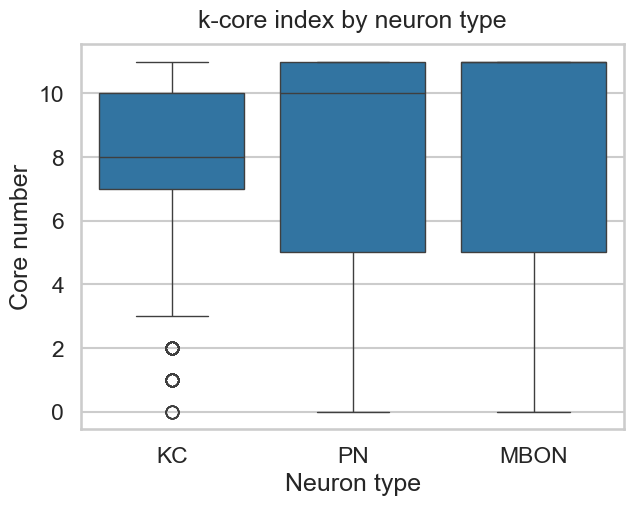

In [63]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df_core, x="type", y="core")
plt.title("k-core index by neuron type")
plt.xlabel("Neuron type")
plt.ylabel("Core number")
plt.show()


The k-core analysis reveals a clear hierarchical organization in the PN–KC–MBON subnetwork.
- Projection neurons predominantly occupy low core numbers, indicating a peripheral structural position consistent with their role as source nodes that inject information into the network.
- Kenyon cells are concentrated at intermediate core levels, showing that they are well embedded and form a stable backbone that integrates and relays signals.
-  MBONs tend to have higher core numbers and dominate the innermost cores, reflecting dense interconnectivity and a central structural role as sink nodes where information converges. Together, these results demonstrate that the subnetwork is hierarchically layered, with topology alone recovering the functional separation between sources, processing units, and outputs.

# Bow Tie

In [67]:
# Strongly connected components
sccs = list(nx.strongly_connected_components(G_roi))

# Largest SCC = core
core = max(sccs, key=len)
core = set(core)

print("Core size:", len(core))


Core size: 5236


In [68]:
IN = set()
OUT = set()

for n in G_roi.nodes():
    if n in core:
        continue

    # Can reach core?
    if any(nx.has_path(G_roi, n, c) for c in core):
        IN.add(n)

    # Reachable from core?
    if any(nx.has_path(G_roi, c, n) for c in core):
        OUT.add(n)

# Clean separation
IN -= OUT
OUT -= IN

print("IN size:", len(IN))
print("OUT size:", len(OUT))


IN size: 366
OUT size: 313


In [69]:
TENDRILS = set(G_roi.nodes()) - core - IN - OUT
print("Tendrils size:", len(TENDRILS))


Tendrils size: 45


In [70]:
def count_types(nodeset):
    return {
        "PN": len(nodeset & pns),
        "KC": len(nodeset & kcs),
        "MBON": len(nodeset & mbons)
    }

print("IN:", count_types(IN))
print("CORE:", count_types(core))
print("OUT:", count_types(OUT))
print("TENDRILS:", count_types(TENDRILS))


IN: {'PN': 111, 'KC': 255, 'MBON': 0}
CORE: {'PN': 402, 'KC': 4772, 'MBON': 62}
OUT: {'PN': 147, 'KC': 134, 'MBON': 32}
TENDRILS: {'PN': 27, 'KC': 16, 'MBON': 2}


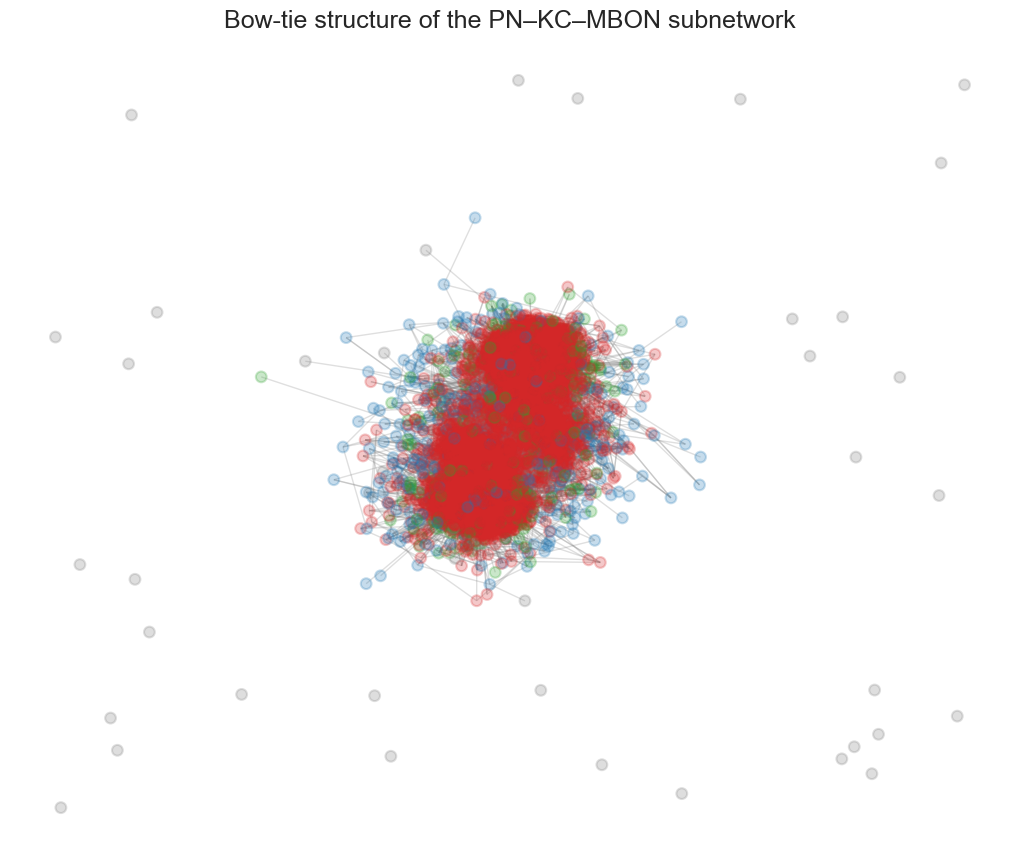

In [71]:
color_map = []

for n in G_roi.nodes():
    if n in IN:
        color_map.append("tab:blue")     # IN
    elif n in core:
        color_map.append("tab:red")      # CORE
    elif n in OUT:
        color_map.append("tab:green")    # OUT
    else:
        color_map.append("tab:gray")     # TENDRILS

pos = nx.spring_layout(G_roi, seed=42)

plt.figure(figsize=(10, 8))
nx.draw(
    G_roi, pos,
    node_color=color_map,
    node_size=60,
    edge_color="gray",
    alpha=0.25,
    arrows=False
)
plt.title("Bow-tie structure of the PN–KC–MBON subnetwork")
plt.axis("off")
plt.show()


In [72]:
layer_pos = {}

for n in G_roi.nodes():
    if n in pns:
        layer_pos[n] = 0   # PN layer
    elif n in kcs:
        layer_pos[n] = 1   # KC layer
    elif n in mbons:
        layer_pos[n] = 2   # MBON layer


In [73]:
pos = {}

layers = {0: [], 1: [], 2: []}
for n, l in layer_pos.items():
    layers[l].append(n)

for l, nodes in layers.items():
    for i, n in enumerate(nodes):
        pos[n] = (l, i)


In [75]:
node_colors = []

for n in G_roi.nodes():
    if n in pns:
        node_colors.append("tab:blue")     # PN
    elif n in kcs:
        node_colors.append("tab:orange")   # KC
    elif n in mbons:
        node_colors.append("tab:green")    # MBON


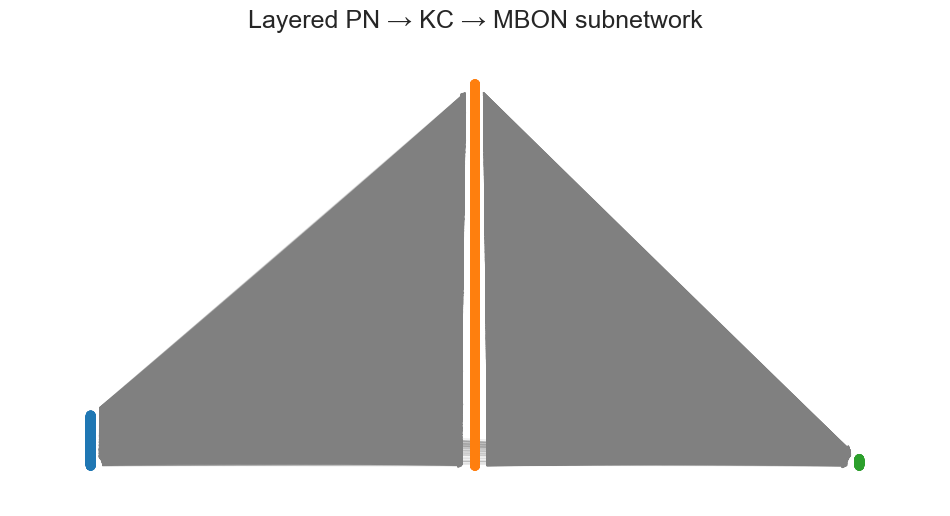

In [76]:
plt.figure(figsize=(12, 6))

nx.draw_networkx_nodes(
    G_roi,
    pos,
    node_color=node_colors,
    node_size=30,
    alpha=0.9
)

nx.draw_networkx_edges(
    G_roi,
    pos,
    arrows=True,
    arrowstyle="->",
    arrowsize=6,
    edge_color="gray",
    alpha=0.15
)

plt.xticks([0, 1, 2], ["PN", "KC", "MBON"])
plt.title("Layered PN → KC → MBON subnetwork")
plt.axis("off")
plt.show()
